# K-Modes Behavioral Clustering

Cluster OULAD students according to categorical e-learning behavior patterns using K-Modes clustering.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
import joblib

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

In [ ]:
student_behaviour = pd.read_csv(
    PROCESSED_DIR / "student_behaviour.csv"
)

print("Shape:", student_behaviour.shape)

student_behaviour.head()

In [ ]:
BEHAVIOUR_FEATURES = [
    "Activity_Level",
    "Learning_Frequency",
    "Learning_Consistency",
    "Content_Preference",
    "Resource_Diversity",
    "Assessment_Engagement",
    "Submission_Behaviour",
    "Inactivity_Pattern"
]

X = student_behaviour[BEHAVIOUR_FEATURES].copy()

X.head()

In [ ]:
X.shape

In [ ]:
X.isnull().sum()

In [ ]:
X.dtypes

In [ ]:
print(
    "Unique behavioral profiles:",
    X.drop_duplicates().shape[0]
)

print(
    "Total students:",
    X.shape[0]
)

In [ ]:
k_values = range(2, 9)

costs = []
models = {}

for k in k_values:

    print(f"Training K={k}")

    model = KModes(
        n_clusters=k,
        init="Huang",
        n_init=5,
        verbose=0,
        random_state=42
    )

    model.fit(X)

    costs.append(model.cost_)
    models[k] = model

In [ ]:
cost_results = pd.DataFrame({
    "K": list(k_values),
    "Cost": costs
})

cost_results

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    costs,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("K-Modes Cost")
plt.title("Elbow Method for K-Modes")
plt.xticks(list(k_values))

plt.show()

In [ ]:
X_encoded = X.copy()

for column in X_encoded.columns:
    X_encoded[column] = pd.Categorical(
        X_encoded[column]
    ).codes

X_encoded.head()

In [ ]:
silhouette_results = []

for k in k_values:

    labels = models[k].labels_

    score = silhouette_score(
        X_encoded,
        labels,
        metric="hamming",
        sample_size=5000,
        random_state=42
    )

    silhouette_results.append(score)

    print(
        f"K={k} | Silhouette={score:.4f}"
    )

In [ ]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Cost": costs,
    "Silhouette": silhouette_results
})

evaluation

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_results,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis Using Hamming Distance")
plt.xticks(list(k_values))

plt.show()

In [ ]:
for k in [3, 4, 5]:

    labels = models[k].labels_

    counts = pd.Series(labels).value_counts().sort_index()

    print(f"\nK = {k}")
    print(counts)

In [ ]:
for k in [3, 4, 5]:

    labels = models[k].labels_

    percentages = (
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\nK = {k}")

    print(
        percentages.round(2)
    )

In [ ]:
candidate_k = 4
candidate_model = models[candidate_k]

In [ ]:
cluster_modes = pd.DataFrame(
    candidate_model.cluster_centroids_,
    columns=BEHAVIOUR_FEATURES
)

cluster_modes.index.name = "Cluster"

cluster_modes

In [ ]:
for k in [3, 4, 5]:

    print(f"\n{'=' * 20}")
    print(f"K = {k}")
    print("=" * 20)

    modes = pd.DataFrame(
        models[k].cluster_centroids_,
        columns=BEHAVIOUR_FEATURES
    )

    display(modes)

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
import joblib

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Abhijith Shetty\Downloads\E-Learning-Behavior-Segmentation


In [2]:
student_behaviour = pd.read_csv(
    PROCESSED_DIR / "student_behaviour.csv"
)

print("Dataset shape:", student_behaviour.shape)

student_behaviour.head()

Dataset shape: (29228, 28)


,id_student,code_module,code_presentation,total_clicks,active_days,active_weeks,first_activity,last_activity,unique_resources,activity_span,...,Content_Preference,unique_activity_types,Resource_Diversity,assessments_attempted,total_assessments,assessment_attempt_ratio,Assessment_Engagement,median_submission_difference,Submission_Behaviour,final_result
0,6516,AAA,2014J,2791,159,39,-23,269,84,292,...,Learning Content,7,Moderate,5.0,6.0,0.833333,High,-2.0,On-Time,Pass
1,8462,DDD,2013J,646,56,17,-6,118,125,124,...,Learning Content,9,Moderate,3.0,7.0,0.428571,Low,-2.0,On-Time,Withdrawn
2,8462,DDD,2014J,10,1,1,10,10,3,0,...,Navigation,3,Narrow,4.0,7.0,0.571429,Medium,-52.5,Early,Withdrawn
3,11391,AAA,2013J,934,40,27,-5,253,55,258,...,Learning Content,6,Narrow,5.0,6.0,0.833333,High,-2.0,On-Time,Pass
4,23629,BBB,2013B,161,16,11,-6,87,11,93,...,Discussion,5,Narrow,4.0,12.0,0.333333,Low,6.0,Late,Fail


In [3]:
BEHAVIOUR_FEATURES = [
    "Activity_Level",
    "Learning_Frequency",
    "Learning_Consistency",
    "Content_Preference",
    "Resource_Diversity",
    "Assessment_Engagement",
    "Submission_Behaviour",
    "Inactivity_Pattern"
]

X = student_behaviour[
    BEHAVIOUR_FEATURES
].copy()

In [4]:
X.head()

,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
0,High,Frequent,Consistent,Learning Content,Moderate,High,On-Time,Moderate Inactivity
1,Medium,Moderate,Consistent,Learning Content,Moderate,Low,On-Time,Low Inactivity
2,Low,Rare,Irregular,Navigation,Narrow,Medium,Early,Low Inactivity
3,Medium,Rare,Moderately Regular,Learning Content,Narrow,High,On-Time,Moderate Inactivity
4,Low,Rare,Irregular,Discussion,Narrow,Low,Late,High Inactivity


In [5]:
print("X shape:", X.shape)

print("\nMissing values:")
print(X.isnull().sum())

X shape: (29228, 8)

Missing values:
Activity_Level           0
Learning_Frequency       0
Learning_Consistency     0
Content_Preference       0
Resource_Diversity       0
Assessment_Engagement    0
Submission_Behaviour     0
Inactivity_Pattern       0
dtype: int64


In [6]:
for feature in BEHAVIOUR_FEATURES:
    print(f"\n--- {feature} ---")
    print(X[feature].value_counts())


--- Activity_Level ---
Activity_Level
High      9749
Medium    9743
Low       9736
Name: count, dtype: int64

--- Learning_Frequency ---
Learning_Frequency
Moderate    9765
Frequent    9746
Rare        9717
Name: count, dtype: int64

--- Learning_Consistency ---
Learning_Consistency
Consistent            15026
Moderately Regular     8050
Irregular              6152
Name: count, dtype: int64

--- Content_Preference ---
Content_Preference
Learning Content    16931
Discussion           5609
Assessment           4384
Navigation           2304
Name: count, dtype: int64

--- Resource_Diversity ---
Resource_Diversity
Diverse     10437
Moderate     9920
Narrow       8871
Name: count, dtype: int64

--- Assessment_Engagement ---
Assessment_Engagement
High      13493
Low       11093
Medium     4642
Name: count, dtype: int64

--- Submission_Behaviour ---
Submission_Behaviour
On-Time               10208
Late                   8486
Early                  7099
No Submission Data     3435
Name: count

## K-Modes Model Selection

In [7]:
k_values = range(2, 9)

costs = []
models = {}

for k in k_values:

    print(f"Training K={k}")

    model = KModes(
        n_clusters=k,
        init="Huang",
        n_init=20,
        verbose=0,
        random_state=42
    )

    model.fit(X)

    costs.append(model.cost_)
    models[k] = model

Training K=2
Training K=3
Training K=4
Training K=5
Training K=6
Training K=7
Training K=8


In [9]:
cost_results = pd.DataFrame({
    "K": list(k_values),
    "Cost": costs
})

cost_results

,K,Cost
0,2,92168.0
1,3,72718.0
2,4,66527.0
3,5,64530.0
4,6,60005.0
5,7,57686.0
6,8,56547.0


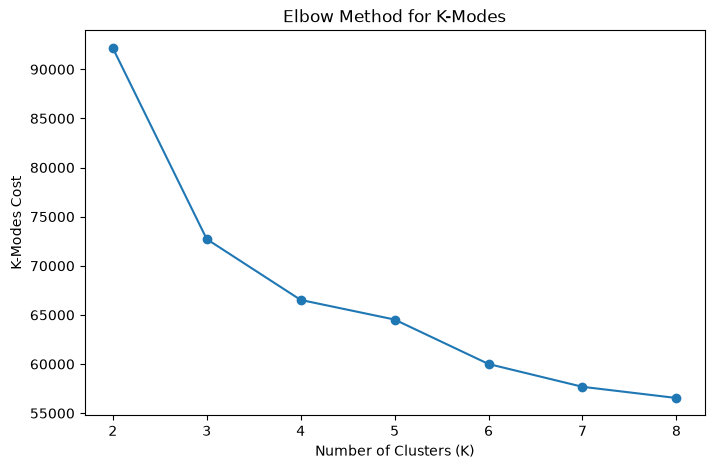

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    costs,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("K-Modes Cost")
plt.title("Elbow Method for K-Modes")
plt.xticks(list(k_values))

plt.show()

## Silhouette Analysis

In [11]:
X_encoded = X.copy()

for column in X_encoded.columns:
    X_encoded[column] = pd.Categorical(
        X_encoded[column]
    ).codes

X_encoded.head()

,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
0,0,0,0,2,1,0,3,2
1,2,1,0,2,1,1,3,1
2,1,2,1,3,2,2,0,1
3,2,2,2,2,2,0,3,2
4,1,2,1,1,2,1,1,0


In [12]:
silhouette_results = []

for k in k_values:

    labels = models[k].labels_

    score = silhouette_score(
        X_encoded,
        labels,
        metric="hamming",
        sample_size=5000,
        random_state=42
    )

    silhouette_results.append(score)

    print(
        f"K={k} | Silhouette={score:.4f}"
    )

K=2 | Silhouette=0.3462
K=3 | Silhouette=0.3556
K=4 | Silhouette=0.3117
K=5 | Silhouette=0.2751
K=6 | Silhouette=0.2319
K=7 | Silhouette=0.2173
K=8 | Silhouette=0.1944


In [13]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Cost": costs,
    "Silhouette": silhouette_results
})

evaluation

,K,Cost,Silhouette
0,2,92168.0,0.346188
1,3,72718.0,0.355644
2,4,66527.0,0.311718
3,5,64530.0,0.275117
4,6,60005.0,0.231912
5,7,57686.0,0.217296
6,8,56547.0,0.194441


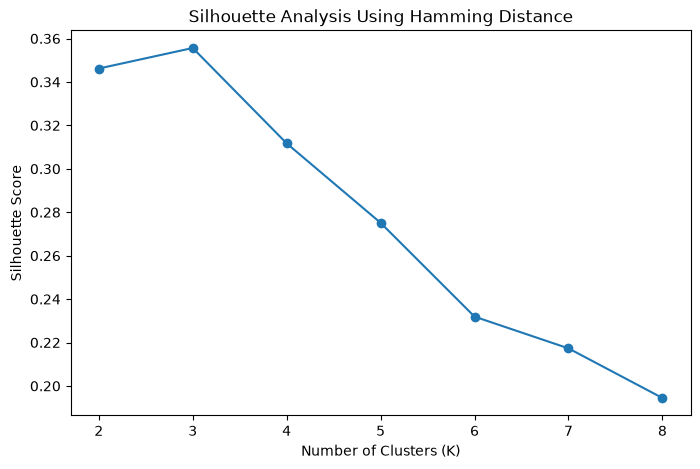

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_results,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis Using Hamming Distance")
plt.xticks(list(k_values))

plt.show()

## Candidate Cluster Comparison

In [15]:
for k in [3, 4, 5]:

    labels = models[k].labels_

    percentages = (
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(f"\nK = {k}")
    print(percentages)


K = 3
0    34.23
1    37.64
2    28.13
Name: proportion, dtype: float64

K = 4
0    31.26
1    18.52
2    20.71
3    29.50
Name: proportion, dtype: float64

K = 5
0    26.45
1    11.64
2    30.96
3    22.38
4     8.57
Name: proportion, dtype: float64


In [16]:
for k in [3, 4, 5]:

    print(f"\n{'=' * 20}")
    print(f"K = {k}")
    print("=" * 20)

    modes = pd.DataFrame(
        models[k].cluster_centroids_,
        columns=BEHAVIOUR_FEATURES
    )

    display(modes)


K = 3


,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
0,Low,Rare,Irregular,Learning Content,Narrow,Low,No Submission Data,High Inactivity
1,High,Frequent,Consistent,Learning Content,Diverse,High,Early,Low Inactivity
2,Medium,Moderate,Moderately Regular,Learning Content,Moderate,High,On-Time,Moderate Inactivity



K = 4


,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
0,Low,Rare,Irregular,Learning Content,Narrow,Low,No Submission Data,High Inactivity
1,Medium,Moderate,Moderately Regular,Learning Content,Moderate,Low,Late,High Inactivity
2,Medium,Moderate,Consistent,Learning Content,Moderate,High,On-Time,Moderate Inactivity
3,High,Frequent,Consistent,Learning Content,Diverse,High,Early,Low Inactivity



K = 5


,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
0,High,Frequent,Consistent,Learning Content,Diverse,High,On-Time,Low Inactivity
1,High,Frequent,Consistent,Learning Content,Diverse,High,Late,Moderate Inactivity
2,Low,Rare,Irregular,Learning Content,Narrow,Low,No Submission Data,High Inactivity
3,Medium,Moderate,Moderately Regular,Learning Content,Moderate,High,On-Time,Moderate Inactivity
4,Medium,Moderate,Consistent,Learning Content,Moderate,Low,Late,Low Inactivity


## Final K-Modes Model

In [17]:
FINAL_K = 4

final_model = models[FINAL_K]

student_behaviour["Cluster"] = final_model.labels_

print(
    student_behaviour["Cluster"]
    .value_counts()
    .sort_index()
)

Cluster
0    9138
1    5414
2    6053
3    8623
Name: count, dtype: int64


In [18]:
final_modes = pd.DataFrame(
    final_model.cluster_centroids_,
    columns=BEHAVIOUR_FEATURES
)

final_modes.index.name = "Cluster"

final_modes

,Activity_Level,Learning_Frequency,Learning_Consistency,Content_Preference,Resource_Diversity,Assessment_Engagement,Submission_Behaviour,Inactivity_Pattern
Cluster,,,,,,,,
0,Low,Rare,Irregular,Learning Content,Narrow,Low,No Submission Data,High Inactivity
1,Medium,Moderate,Moderately Regular,Learning Content,Moderate,Low,Late,High Inactivity
2,Medium,Moderate,Consistent,Learning Content,Moderate,High,On-Time,Moderate Inactivity
3,High,Frequent,Consistent,Learning Content,Diverse,High,Early,Low Inactivity


In [19]:
CLUSTER_NAMES = {
    0: "Low-Engagement Inactive Learners",
    1: "Irregular Late-Submission Learners",
    2: "Steady Assessment-Engaged Learners",
    3: "Highly Engaged Consistent Learners"
}

student_behaviour["Cluster_Name"] = (
    student_behaviour["Cluster"]
    .map(CLUSTER_NAMES)
)

In [20]:
student_behaviour[
    [
        "Cluster",
        "Cluster_Name"
    ]
].value_counts()

Cluster  Cluster_Name                      
0        Low-Engagement Inactive Learners      9138
3        Highly Engaged Consistent Learners    8623
2        Steady Assessment-Engaged Learners    6053
1        Irregular Late-Submission Learners    5414
Name: count, dtype: int64

In [21]:
cluster_distribution = (
    student_behaviour["Cluster_Name"]
    .value_counts()
    .reset_index()
)

cluster_distribution.columns = [
    "Cluster",
    "Students"
]

cluster_distribution

,Cluster,Students
0,Low-Engagement Inactive Learners,9138
1,Highly Engaged Consistent Learners,8623
2,Steady Assessment-Engaged Learners,6053
3,Irregular Late-Submission Learners,5414


In [22]:
cluster_percentage = (
    student_behaviour["Cluster_Name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cluster_percentage

Cluster_Name
Low-Engagement Inactive Learners      31.26
Highly Engaged Consistent Learners    29.50
Steady Assessment-Engaged Learners    20.71
Irregular Late-Submission Learners    18.52
Name: proportion, dtype: float64

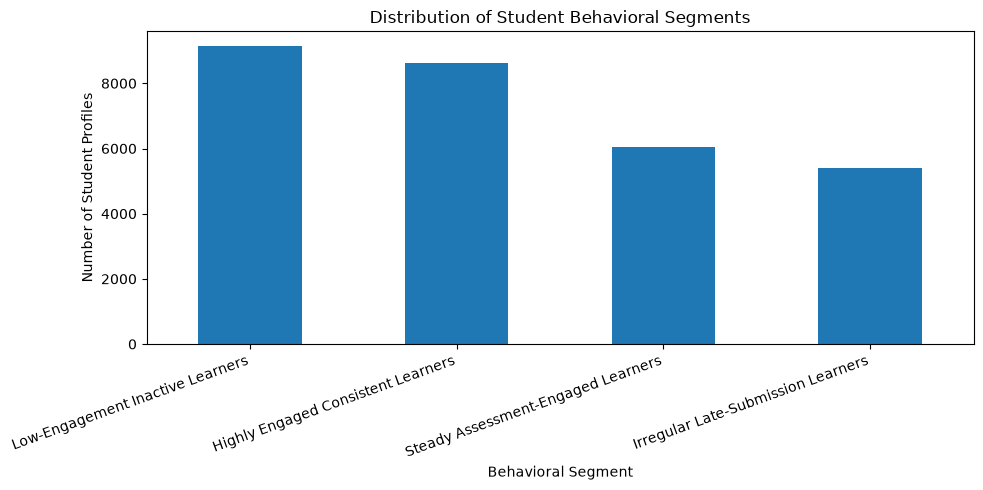

In [23]:
cluster_counts = (
    student_behaviour["Cluster_Name"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Behavioral Segment")
plt.ylabel("Number of Student Profiles")
plt.title("Distribution of Student Behavioral Segments")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

In [24]:
outcome_table = pd.crosstab(
    student_behaviour["Cluster_Name"],
    student_behaviour["final_result"]
)

outcome_table

final_result,Distinction,Fail,Pass,Withdrawn
Cluster_Name,,,,
Highly Engaged Consistent Learners,2115,509,5683,316
Irregular Late-Submission Learners,235,1820,1874,1485
Low-Engagement Inactive Learners,58,3666,692,4722
Steady Assessment-Engaged Learners,616,683,4109,645


In [25]:
outcome_percentage = pd.crosstab(
    student_behaviour["Cluster_Name"],
    student_behaviour["final_result"],
    normalize="index"
).mul(100).round(2)

outcome_percentage

final_result,Distinction,Fail,Pass,Withdrawn
Cluster_Name,,,,
Highly Engaged Consistent Learners,24.53,5.90,65.91,3.66
Irregular Late-Submission Learners,4.34,33.62,34.61,27.43
Low-Engagement Inactive Learners,0.63,40.12,7.57,51.67
Steady Assessment-Engaged Learners,10.18,11.28,67.88,10.66


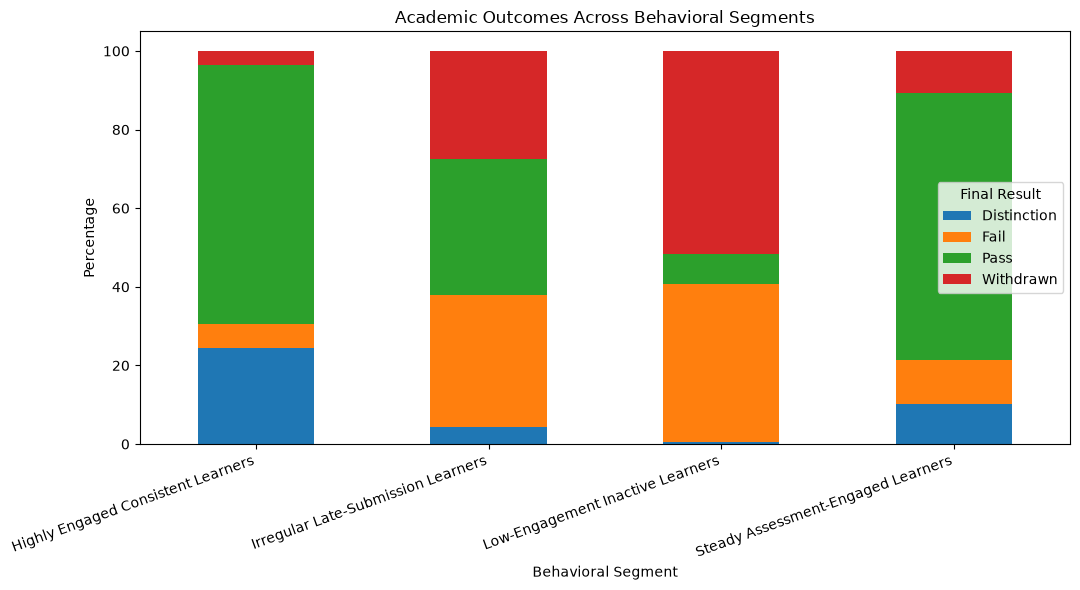

In [26]:
outcome_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.xlabel("Behavioral Segment")
plt.ylabel("Percentage")
plt.title(
    "Academic Outcomes Across Behavioral Segments"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Final Result"
)

plt.tight_layout()
plt.show()

In [27]:
joblib.dump(
    final_model,
    MODELS_DIR / "kmodes_model.pkl"
)

print(
    "Model saved:",
    MODELS_DIR / "kmodes_model.pkl"
)

Model saved: c:\Users\Abhijith Shetty\Downloads\E-Learning-Behavior-Segmentation\models\kmodes_model.pkl


In [28]:
model_metadata = {
    "features": BEHAVIOUR_FEATURES,
    "cluster_names": CLUSTER_NAMES,
    "n_clusters": FINAL_K
}

joblib.dump(
    model_metadata,
    MODELS_DIR / "model_metadata.pkl"
)

['c:\\Users\\Abhijith Shetty\\Downloads\\E-Learning-Behavior-Segmentation\\models\\model_metadata.pkl']

In [29]:
student_behaviour.to_csv(
    PROCESSED_DIR / "student_behaviour_clustered.csv",
    index=False
)

print("Clustered dataset saved.")

Clustered dataset saved.


In [30]:
outcome_percentage

final_result,Distinction,Fail,Pass,Withdrawn
Cluster_Name,,,,
Highly Engaged Consistent Learners,24.53,5.90,65.91,3.66
Irregular Late-Submission Learners,4.34,33.62,34.61,27.43
Low-Engagement Inactive Learners,0.63,40.12,7.57,51.67
Steady Assessment-Engaged Learners,10.18,11.28,67.88,10.66


## Cluster Outcome Interpretation

The discovered behavioral segments show clear differences in academic outcomes.

- Highly Engaged Consistent Learners achieved the strongest outcomes, with most students passing or receiving distinction.
- Steady Assessment-Engaged Learners also showed strong academic performance.
- Irregular Late-Submission Learners had substantially higher failure and withdrawal rates.
- Low-Engagement Inactive Learners formed the highest-risk segment, with the majority either failing or withdrawing.

These results indicate that the K-Modes clusters capture meaningful behavioral differences associated with academic outcomes. Since final_result was not used during clustering, it serves as an external validation of the discovered behavioral segments.

In [31]:
joblib.dump(
    final_model,
    MODELS_DIR / "kmodes_model.pkl"
)

model_metadata = {
    "features": BEHAVIOUR_FEATURES,
    "cluster_names": CLUSTER_NAMES,
    "n_clusters": FINAL_K
}

joblib.dump(
    model_metadata,
    MODELS_DIR / "model_metadata.pkl"
)

student_behaviour.to_csv(
    PROCESSED_DIR / "student_behaviour_clustered.csv",
    index=False
)

print("Model, metadata, and clustered dataset saved successfully.")

Model, metadata, and clustered dataset saved successfully.


In [32]:
print((MODELS_DIR / "kmodes_model.pkl").exists())
print((MODELS_DIR / "model_metadata.pkl").exists())
print((PROCESSED_DIR / "student_behaviour_clustered.csv").exists())

True
True
True
